In [2]:
import json
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, AutoTokenizer, get_scheduler
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from tqdm.notebook import tqdm, trange
from time import perf_counter
from PIL import Image
import pandas as pd
#from google.colab import drive
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

print("All dependencies present")

All dependencies present


In [3]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

In [4]:
seed_val = 42
set_seed(seed_val)

In [5]:
#load in dataframe
pd.set_option('display.max_columns', None)

with open("./content/2024-08-012_imagej_feats_inverted_no_dfs_df.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

feats_df.shape

(39517, 111)

In [6]:
## Cutting down the data down to ~500 points
# find ranges for confined scan
param_df = feats_df[feats_df["dir"] != '/content/05-09-2024_all_images/']

cut = True
cut_images = 500

if cut:
    param_df = param_df.sample(frac=float(cut_images / param_df.shape[0]), random_state = 42)

#param_df = feats_df

param_df.shape

# param_df.columns()

(500, 111)

In [8]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


feat_array_scaled = pd.DataFrame(sc.fit_transform(feats_df[feats_df.columns[13:-3]])) # 14th column - third from last (exclusive)


# feat_array_scaled = sc.fit_transform(feat_array_scaled)


print(feat_array_scaled.shape)


# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(feat_array_scaled)


explained_variance = pca.explained_variance_ratio_

print(explained_variance)

feats_df["pc1"] = pca_data[:,0]
feats_df["pc2"] = pca_data[:,1]


# PCA components (loadings)
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(pca.components_))],
                        index=feat_array_scaled.columns)

print("PCA Loadings:")
print(loadings)

# Find top features for each principal component
top_features = {}
for pc in loadings.columns:
    top_features[pc] = loadings[pc].abs().nlargest(3).index.tolist()  # Top 3 contributing features
print("\nTop Contributing Features per Principal Component:")
print(top_features)


(39517, 95)
[0.40335025 0.24936881]
PCA Loadings:
         PC1       PC2
0   0.063943  0.102919
1  -0.020598 -0.123470
2  -0.022217 -0.141839
3  -0.120494 -0.134209
4   0.088172 -0.078721
..       ...       ...
90 -0.116973  0.128303
91  0.098154 -0.048375
92  0.076827 -0.074302
93  0.096977 -0.094048
94 -0.124029  0.111705

[95 rows x 2 columns]

Top Contributing Features per Principal Component:
{'PC1': [26, 45, 52], 'PC2': [25, 9, 58]}


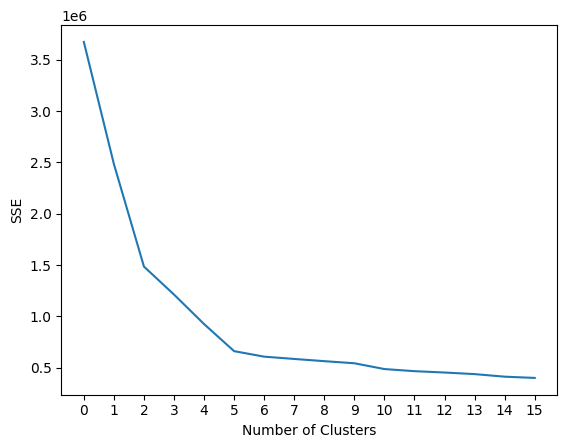

In [9]:
# K_means clustering
from sklearn.cluster import KMeans

#Find optimum number of clusters
sse = [] #SUM OF SQUARED ERROR
for k in range(1,17):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(feat_array_scaled)
    sse.append(km.inertia_)

fig, ax = plt.subplots()
ax.set(xlabel = "Number of Clusters", ylabel = "SSE", xticks = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])

ax.plot(sse)

plt.show()

In [13]:
# K_means clustering
from sklearn.cluster import KMeans

def create_cluster_df(num_clusters = 6, clustering_column_name = 'cluster'):
    working_df = feats_df
    km = KMeans(n_clusters = num_clusters, init='k-means++', n_init=50, max_iter=300,
                tol=0.0001, random_state=42)
    clusters = km.fit(feat_array_scaled)
    working_df[clustering_column_name] = clusters.labels_
    # create entry in dictionary
    return working_df

test_five_df = create_cluster_df(5, 'classifier_pred_class')
test_five_df

,Ua,Ui,Ga,Gi,Ba,Da,Di,pattern,noise,path,seed,dir,feat_bool,num_spots,Mean,Median,Area_mean,Area_std,X_mean,X_std,Y_mean,Y_std,Perim._mean,Perim._std,BX_mean,BX_std,BY_mean,BY_std,Width_mean,Width_std,Height_mean,Height_std,Major_mean,Major_std,Minor_mean,Minor_std,Angle_mean,Angle_std,Circ._mean,Circ._std,Feret_mean,Feret_std,IntDen_mean,IntDen_std,%Area_mean,%Area_std,RawIntDen_mean,RawIntDen_std,FeretX_mean,FeretX_std,FeretY_mean,FeretY_std,FeretAngle_mean,FeretAngle_std,MinFeret_mean,MinFeret_std,AR_mean,AR_std,Round_mean,Round_std,Solidity_mean,Solidity_std,num_spots_inverted,Mean_inverted,Median_inverted,Area_inverted_mean,Area_inverted_std,X_inverted_mean,X_inverted_std,Y_inverted_mean,Y_inverted_std,Perim._inverted_mean,Perim._inverted_std,BX_inverted_mean,BX_inverted_std,BY_inverted_mean,BY_inverted_std,Width_inverted_mean,Width_inverted_std,Height_inverted_mean,Height_inverted_std,Major_inverted_mean,Major_inverted_std,Minor_inverted_mean,Minor_inverted_std,Angle_inverted_mean,Angle_inverted_std,Circ._inverted_mean,Circ._inverted_std,Feret_inverted_mean,Feret_inverted_std,IntDen_inverted_mean,IntDen_inverted_std,%Area_inverted_mean,%Area_inverted_std,RawIntDen_inverted_mean,RawIntDen_inverted_std,FeretX_inverted_mean,FeretX_inverted_std,FeretY_inverted_mean,FeretY_inverted_std,FeretAngle_inverted_mean,FeretAngle_inverted_std,MinFeret_inverted_mean,MinFeret_inverted_std,AR_inverted_mean,AR_inverted_std,Round_inverted_mean,Round_inverted_std,Solidity_inverted_mean,Solidity_inverted_std,pc1,pc2,c;,classifier_pred_class
0,0.011652,0.1066,0.115805,0.061599,-0.043244,0.007928,0.559698,0,2,0.png,0,/content/Images3/,1,1,255.000,255,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,797.657000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.790000,0.000000,282.843000,0.000000,1.020000e+07,0.000000,100.0,0.0,1.020000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0,0.000,0,40000.0,0.0,100.000,0.0,100.000,0.0,800.000,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.000,0.0,200.0,0.0,1.000,0.0,1.000,0.0,1.000,0.0,-4.316102,-2.970861,3,3
1,0.025122,0.063822,0.071957,0.106327,-0.113131,0.009186,0.611871,1,2,1.png,1,/content/Images3/,1,70,5.489,0,12.300000,2.548669,99.395943,58.506181,97.530229,58.913237,12.282143,1.400962,97.371429,58.453442,95.528571,58.843551,4.071429,0.723512,4.057143,0.753766,4.245571,0.439294,3.664200,0.511781,55.108900,57.413924,0.958686,0.069883,4.926700,0.412294,3.136500e+03,649.910626,100.0,0.0,3.136500e+03,649.910626,97.942857,58.572760,96.014286,58.843981,120.129000,30.775307,3.653171,0.564778,1.177686,0.183575,0.866686,0.115368,0.879486,0.067138,1,249.511,255,39139.0,0.0,99.998,0.0,100.022,0.0,811.882,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,223.351,0.0,223.117,0.0,38.796,0.0,0.746,0.0,282.843,0.0,9980445.0,0.0,100.0,0.0,9980445.0,0.0,0.0,0.0,200.0,0.0,45.000,0.0,200.0,0.0,1.001,0.0,0.999,0.0,0.979,0.0,3.426621,5.976980,0,0
2,0.014455,0.085124,0.091124,0.113974,-0.060333,0.001776,1.798215,0,2,2.png,2,/content/Images3/,1,1,255.000,255,40000.000000,0.000000,100.000000,0.000000,100.000000,0.000000,797.657000,0.000000,0.000000,0.000000,0.000000,0.000000,200.000000,0.000000,200.000000,0.000000,225.676000,0.000000,225.676000,0.000000,0.000000,0.000000,0.790000,0.000000,282.843000,0.000000,1.020000e+07,0.000000,100.0,0.0,1.020000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,200.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0,0.000,0,40000.0,0.0,100.000,0.0,100.000,0.0,800.000,0.0,0.0,0.0,0.0,0.0,200.0,0.0,200.0,0.0,225.676,0.0,225.676,0.0,0.000,0.0,0.785,0.0,282.843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.000,0.0,200.0,0.0,1.000,0.0,1.000,0.0,1.000,0.0,-4.316102,-2.

In [51]:
# K_means clustering
from sklearn.cluster import KMeans

num_clusters = 6
cluster_dicts = {}

for c in range(num_clusters):
    print(c)
    working_df = feats_df
    km = KMeans(n_clusters = num_clusters, init='k-means++', n_init=50, max_iter=300,
                tol=0.0001, random_state=42)
    clusters = km.fit(feat_array_scaled)
    working_df["cluster"] = clusters.labels_
    # create entry in dictionary
    cluster_dicts[str(c)] = working_df

0
1
2
3
4
5


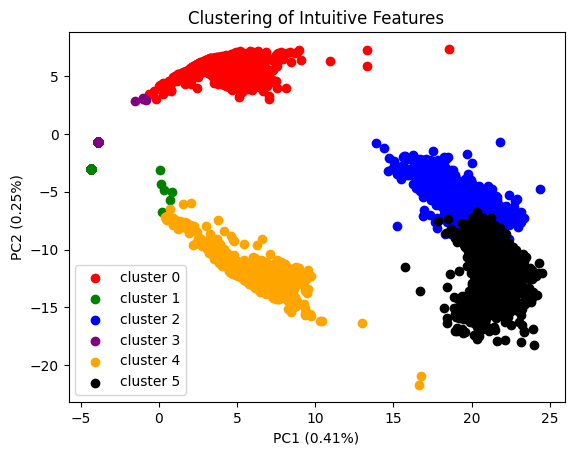

In [52]:
clusters = np.unique(np.array(feats_df["cluster"])) # list of unique clusters

cluster_dfs = [] # list of dfs for each cluster

for i in clusters:
  df = feats_df[feats_df["cluster"] == i]
  df.reset_index(inplace = True, drop = True)
  cluster_dfs.append(df)


# plot the data

fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink", "yellow", "brown", 'gray', 'cyan']

for j in clusters:
  df = cluster_dfs[j]
  ax.scatter(df["pc1"], df["pc2"], c = colors[j], label = "cluster " + str(j))


leg = ax.legend(loc="lower left")

ax.set(xlabel = "PC1 (0.41%)", ylabel = "PC2 (0.25%)", title = "Clustering of Intuitive Features")
plt.show()


